# Tutorial #1

Import libraries

In [110]:
import os
from image_common_utils import show_image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_random_seed(seed_value): Keras uses its source of randomness regardless Theano or TensorFlow.

In addition, TensorFlow has its own random number generator that must also be seeded by calling the set_random_seed() function immediately after the NumPy random number generator.

In [126]:
seed_value = 123; np.random.seed(seed_value)

Import image_common_utils file

In [137]:
exec(open(os.path.abspath('image_common_utils.py')).read())

Basic exploration by reading local image

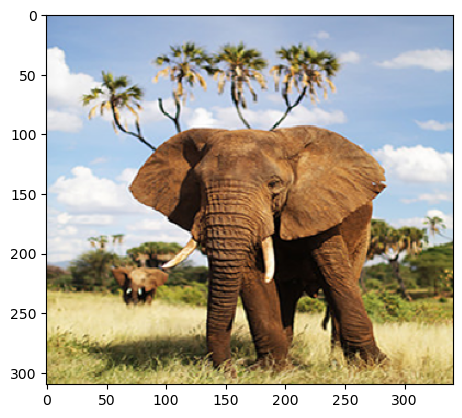

In [149]:
from skimage.io import imread
img_path = 'image_data/elephant.png' # elephant
img = imread(img_path)
img.shape # H x W x C
img.size # multiplication of HxWxC
type(img)
img.dtype
plt.imshow(img)
plt.show()

Normalise

<class 'numpy.ndarray'>
(310, 341, 4)


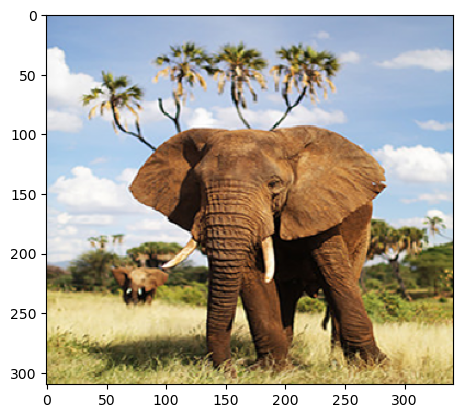

In [157]:
x = img/255
print(type(x))
print(x.shape) # H x W x C
plt.imshow(x)

Gray image reading

(310, 341)
105710


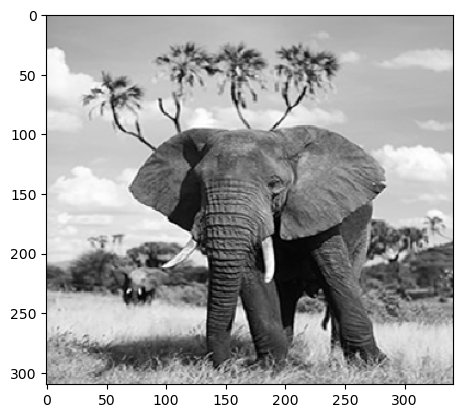

In [163]:
img = imread(img_path, as_gray=True)
print(img.shape) # H x W x C
print(img.size) # multiplication of WxHxC
type(img)
plt.imshow(img, cmap=plt.get_cmap('gray')) # cm.gray
plt.show()

Gray to Black and White


(Pixel range is 0...255, 256/2 = 128)

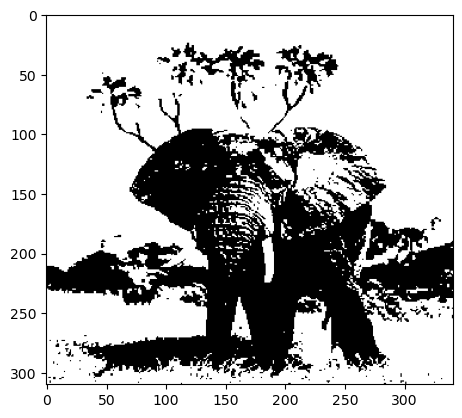

In [167]:
np.min(img), np.max(img)
cutoff = np.max(img)/2
img[img < cutoff] = 0    # Black
img[img >= cutoff] = 1 # White
plt.imshow(img, cmap=plt.get_cmap('gray')) # cm.gray
plt.show()

### Common Functions

lot the histogram of an image (gray-scale or RGB) on `ax`.

Calculate histogram using `skimage.exposure.histogram`
and plot as filled line. If an image has a 3rd dimension, assume it's RGB and plot each channel separately.

In [172]:
def plot_histogram(image, ax=None, **kwargs):
    from skimage import exposure

    ax = ax if ax is not None else plt.gca()

    if image.ndim == 2:
        _plot_histogram(ax, image, color='black', **kwargs)
    elif image.ndim == 3:
        # `channel` is the red, green, or blue channel of the image.
        for channel, channel_color in zip(iter_channels(image), 'rgb'):
            _plot_histogram(ax, channel, color=channel_color, **kwargs)

    return

# Helper of above
def _plot_histogram(ax, image, alpha=0.3, **kwargs):
    # Use skimage's histogram function which has nice defaults for integer and float images.
    hist, bin_centers = exposure.histogram(image)
    ax.fill_between(bin_centers, hist, alpha=alpha, **kwargs)
    ax.set_xlabel('intensity')
    ax.set_ylabel('# pixels')
    return
# Helper of above
def iter_channels(color_image):
    """Yield color channels of an image."""
    # Roll array-axis so that we iterate over the color channels of an image.
    for channel in np.rollaxis(color_image, -1):
        yield channel
    return

# Helper of above
def match_axes_height(ax_src, ax_dst):
    """ Match the axes height of two axes objects.
    The height of `ax_dst` is synced to that of `ax_src`.
    """
    # HACK: plot geometry isn't set until the plot is drawn
    plt.draw()
    dst = ax_dst.get_position()
    src = ax_src.get_position()
    ax_dst.set_position([dst.xmin, src.ymin, dst.width, src.height])
    return

Plot an image side-by-side with its histogram.

* Plot the image next to the histogram

* Plot each RGB channel separately (if input is color)

* Automatically flatten channels

* Select reasonable bins based on the image's dtype

See `plot_histogram` for information on how the histogram is plotted.
    

In [177]:
def imshow_with_histogram(image, **kwargs):

    width, height = plt.rcParams['figure.figsize']
    fig, (ax_image, ax_hist) = plt.subplots(ncols=2, figsize=(2*width, height))

    kwargs.setdefault('cmap', plt.cm.gray)
    ax_image.imshow(image, **kwargs)
    plot_histogram(image, ax=ax_hist)

    # pretty it up
    ax_image.set_axis_off()
    match_axes_height(ax_image, ax_hist)
    return ax_image, ax_hist

Plot CDF

In [184]:
def plot_cdf(image, ax=None):
    img_cdf, bins = exposure.cumulative_distribution(image)
    ax.plot(bins, img_cdf, 'r')
    ax.set_ylabel("Fraction of pixels below intensity")
    return

Basic exploration by inbuilt images - Explore various `Numpy` features

Images manipulated by scikit-image are simply `NumPy` arrays. Hence, a large fraction of operations on images will just consist in using NumPy

In [188]:
from skimage import data
camera = data.camera()
type(camera)

numpy.ndarray

Retrieving the geometry of the image and the number of pixels

In [195]:
camera.shape

(512, 512)

In [197]:
camera.size

262144

Retrieving statistical information about gray values

In [206]:
camera.min(), camera.max(), camera.mean()

(0, 255, 129.06072616577148)

NumPy indexing: NumPy indexing can be used both for looking at pixel values, and to modify pixel value

In [209]:
camera[10, 20] # 200 # Get the value of the pixel on the 10th row and 20th column
camera[3, 10] = 0 # # Set to black the pixel on the 3rd row and 10th column

Be careful: in NumPy indexing, the first dimension (camera.shape[0]) corresponds to rows, while the second (camera.shape[1]) corresponds to columns, with the origin (camera[0, 0]) on the top-left corner. This matches  matrix/linear algebra notation, but is in contrast to Cartesian(x, y) coordinates. See Coordinate conventions below for more details.

Beyond individual pixels, it is possible to access / modify values of whole sets of pixels, using the different indexing possibilities of NumPy.

### Slicing

Set to black the ten first lines

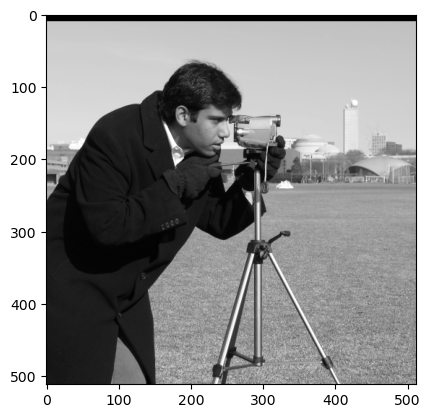

In [216]:
camera[:10] = 0

show_image(camera)

### Masking

(indexing with masks of booleans)

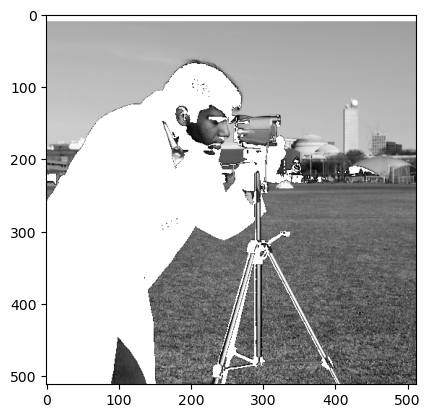

In [221]:
mask = camera < 87 # Just random to mask extreme black points

# Set to "white" (255) pixels where mask is True
camera[mask] = 255

show_image(camera)

### Fancy indexing

(indexing with sets of indices)

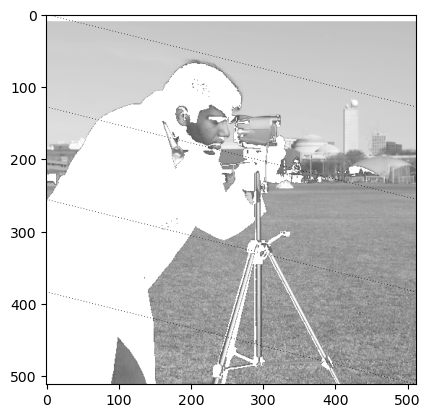

In [225]:
inds_r = np.arange(len(camera))
inds_c = 4 * inds_r % len(camera)
camera[inds_r, inds_c] = 0
show_image(camera)

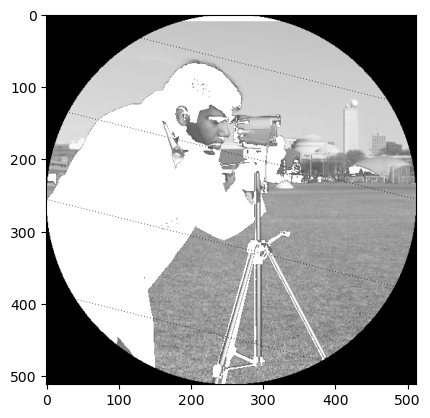

In [226]:
nrows, ncols = camera.shape
row, col = np.ogrid[:nrows, :ncols]
row.shape, col.shape
len(row), len(col[0])
cnt_row, cnt_col = nrows / 2, ncols / 2
outer_disk_mask = ((row - cnt_row)**2 + (col - cnt_col)**2 > (nrows / 2)**2)
camera[outer_disk_mask] = 0
show_image(camera)

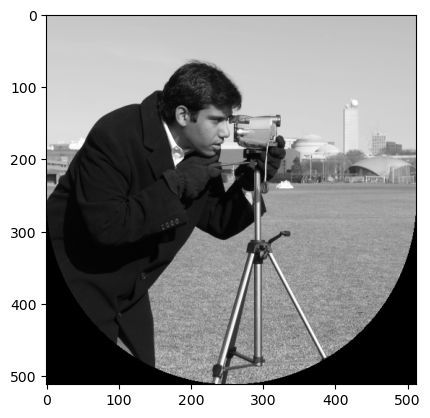

In [227]:
lower_half = row > cnt_row
lower_half_disk = np.logical_and(lower_half, outer_disk_mask)
camera = data.camera()
camera[lower_half_disk] = 0
show_image(camera)

Color images

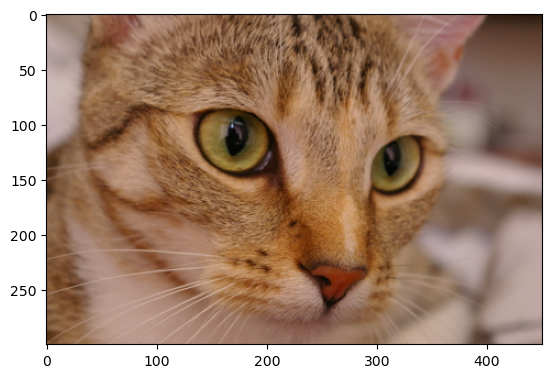

In [231]:
cat = data.chelsea()
type(cat)
cat.shape #(300, 451, 3) This shows that cat is a 300-by-451 pixel image with three channels (red, green, and blue). As before, we can get and set pixel values:
show_image(cat, None)

In [232]:
cat[10, 20]

array([151, 129, 115], dtype=uint8)

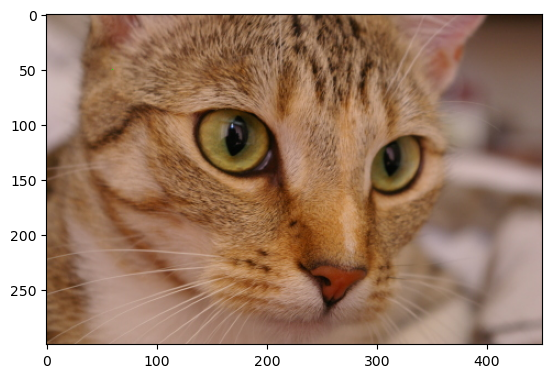

In [234]:
# set the pixel at row 51, column 61 to green
cat[50, 60] = [0, 255, 0] # [red, green, blue]
show_image(cat, None) # see on mspaint

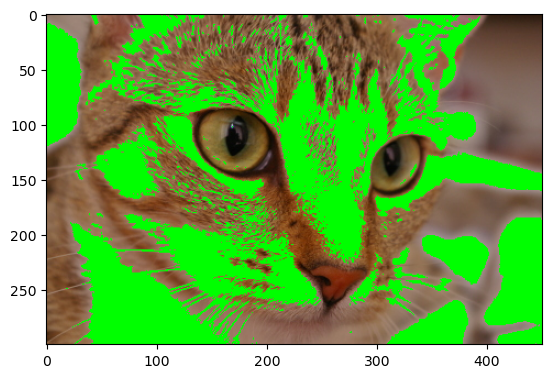

In [235]:
cat = data.chelsea()
some_threshold = cat[:, :, 0] > 160
cat[some_threshold] = [0, 255, 0] # RGB
show_image(cat, None) # More greenish

In [237]:
from skimage.color import rgb2gray

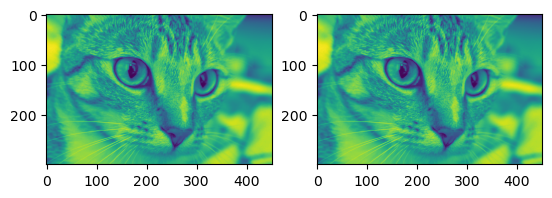

In [238]:
cat = data.chelsea()
factor_multiplication = [0.2126, 0.7152, 0.0722] # RGB as per research
cat_manual = cat @ factor_multiplication # matrix multiplication, @, to convert an RGB image to a grayscale luminance image.
cat_manual.shape
cat_library = rgb2gray(cat)
cat_library.shape

show_image([cat_manual,cat_library], None)

In [239]:
# Error if any
np.mean(np.abs(cat_manual - cat_library)) 

116.90693642601916

Image Processing by exploring skimage.feature

In [242]:
from PIL import Image
from skimage.io import imread
from skimage.feature import blob_log # blob_dog, blob_doh

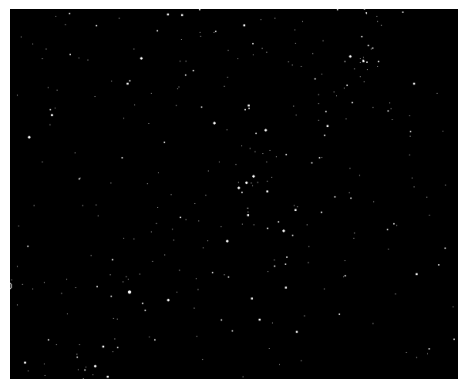

In [243]:
img = Image.open("image_data/wint_sky.gif").convert("L")  # Convert to grayscale
im = np.array(img)

# Display the image
plt.imshow(im, cmap='gray')
plt.axis('off')  # Optionally hide the axes
plt.show()

In [244]:
blobs_log = blob_log(im, max_sigma=30, num_sigma=10, threshold=.1)
blobs_log.shape

(308, 3)

In [245]:
blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

In [247]:
numrows = len(blobs_log)
print("Number of white dots counted : " ,numrows)

Number of white dots counted :  308


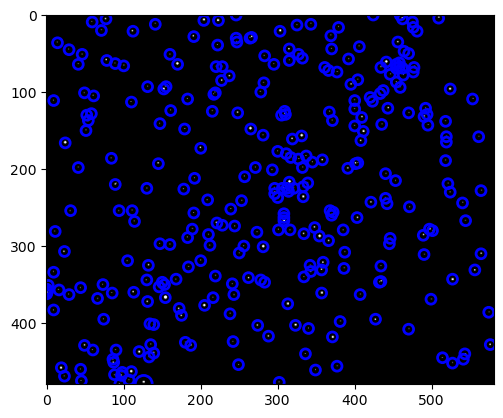

In [248]:
fig, ax = plt.subplots(1, 1)
plt.imshow(im, cmap=plt.get_cmap('gray'))
for blob in blobs_log:
    y, x, r = blob
    c = plt.Circle((x, y), r+5, color='blue', linewidth=2, fill=False)
    ax.add_patch(c)
plt.show()

del(im, blobs_log)

More exploration

In [252]:
from skimage import img_as_float, img_as_ubyte
from skimage import data

In [254]:
image = data.chelsea()

image_float = img_as_float(image) # Try to use it most of the times
image_ubyte = img_as_ubyte(image)

print("type, min, max, Shape:", image.dtype, image.min(), image.max(), image.shape)
print("type, min, max, Shape:", image_float.dtype, image_float.min(), image_float.max(), image_float.shape)
print("type, min, max, Shape:", image_ubyte.dtype, image_ubyte.min(), image_ubyte.max(), image_ubyte.shape)
print("231/255 =", 231.0/255.0)

type, min, max, Shape: uint8 0 231 (300, 451, 3)
type, min, max, Shape: float64 0.0 0.9058823529411765 (300, 451, 3)
type, min, max, Shape: uint8 0 231 (300, 451, 3)
231/255 = 0.9058823529411765


In [255]:
X, Y = np.ogrid[-5:5:0.1, -5:5:0.1] # Start from -5 with step 0.1 and go till 4.9 (5 - 0.1)
R = np.exp(-(X**2 + Y**2) / 20)

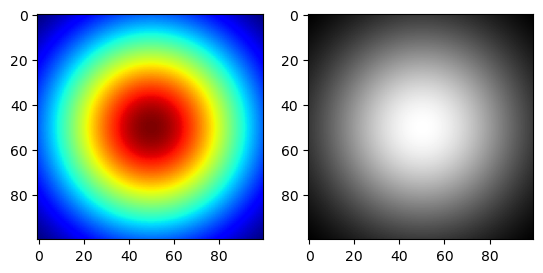

In [256]:
fig, (ax_jet, ax_gray) = plt.subplots(1, 2)
ax_jet.imshow(R, cmap='jet')
ax_gray.imshow(R, cmap='gray')

In [260]:
from skimage import data

In [262]:
color_image = data.chelsea()
print(color_image.shape)

(300, 451, 3)


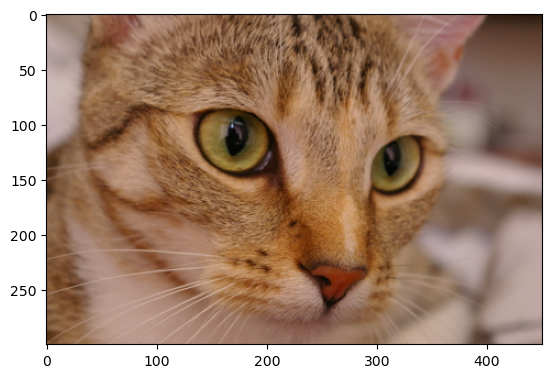

In [266]:
plt.imshow(color_image)

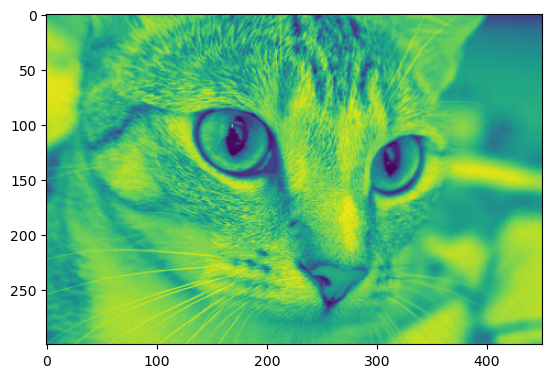

In [268]:
red_channel = color_image[:, :, 0] 
plt.imshow(red_channel)

In [270]:
red_channel.shape

(300, 451)

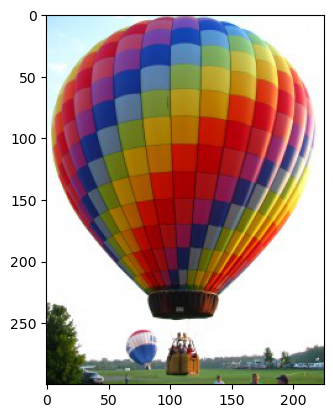

In [272]:
from skimage import io
color_image = io.imread('./image_data/balloon.jpg')
plt.imshow(color_image)

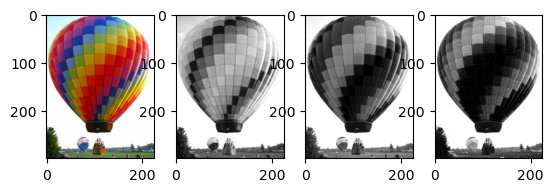

In [275]:
red_image = color_image[:, :, 0]
green_image = color_image[:, :, 1]
blue_image = color_image[:, :, 2]

show_image([color_image, red_image, green_image, blue_image], row_plot = 1)

In [276]:
color_patches = color_image.copy()

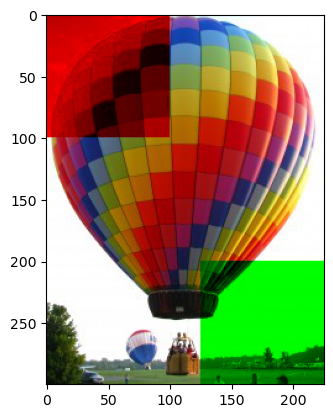

In [281]:
color_patches[:100, :100, 1:] = 0
# Remove red (0) & blue (2) from bottom-right corner.
color_patches[-100:, -100:, (0, 2)] = 0
plt.imshow(color_patches)


Histograms

In [286]:
from skimage import exposure

(<Axes: >, <Axes: xlabel='intensity', ylabel='# pixels'>)

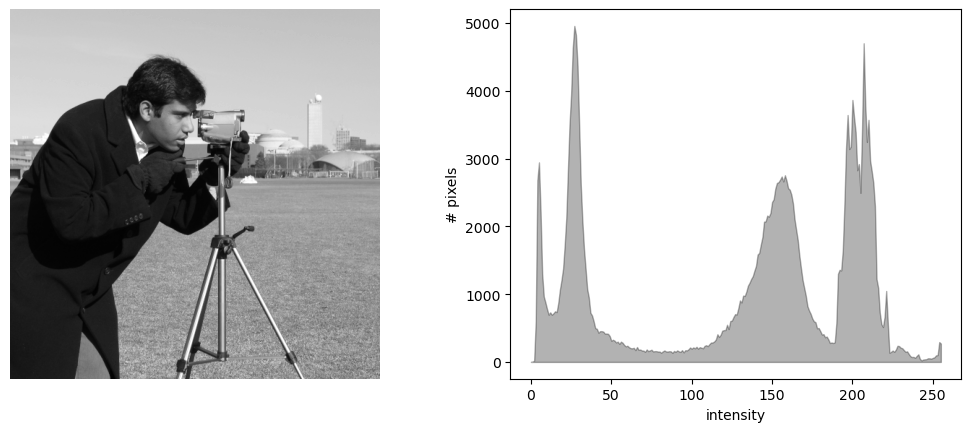

In [287]:
camera = data.camera()
imshow_with_histogram(camera)

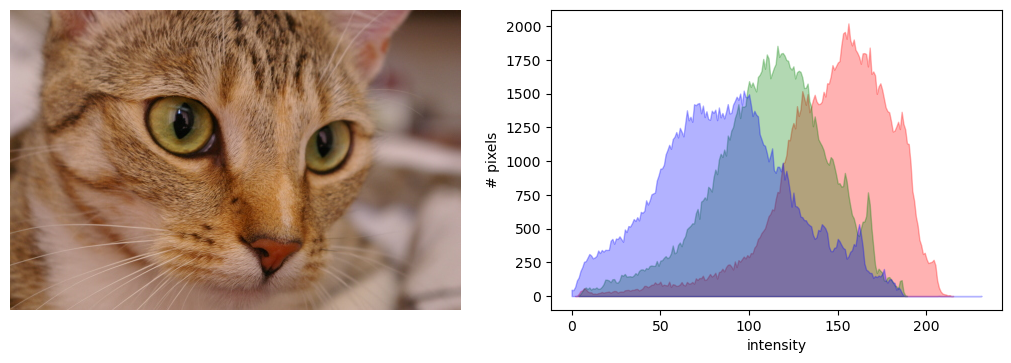

In [289]:
cat = data.chelsea()
imshow_with_histogram(cat);

(<Axes: >, <Axes: xlabel='intensity', ylabel='# pixels'>)

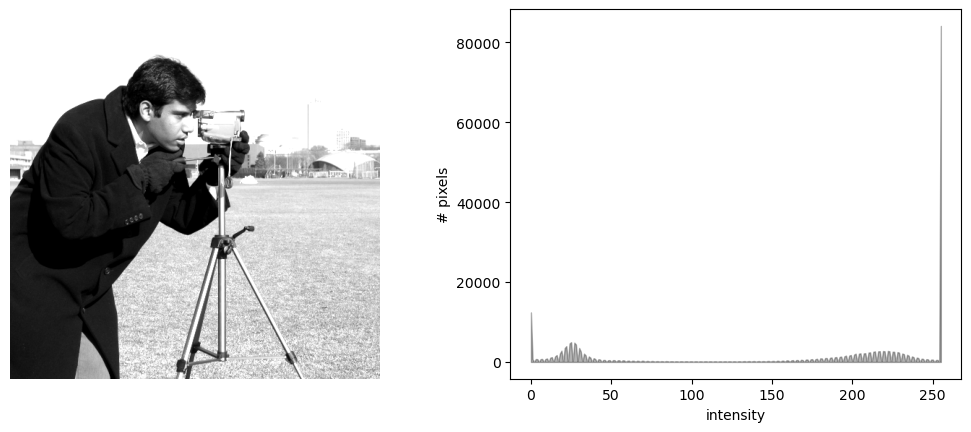

In [292]:
high_contrast = exposure.rescale_intensity(camera, in_range=(10, 180)) # set to (0, 255)
imshow_with_histogram(high_contrast)

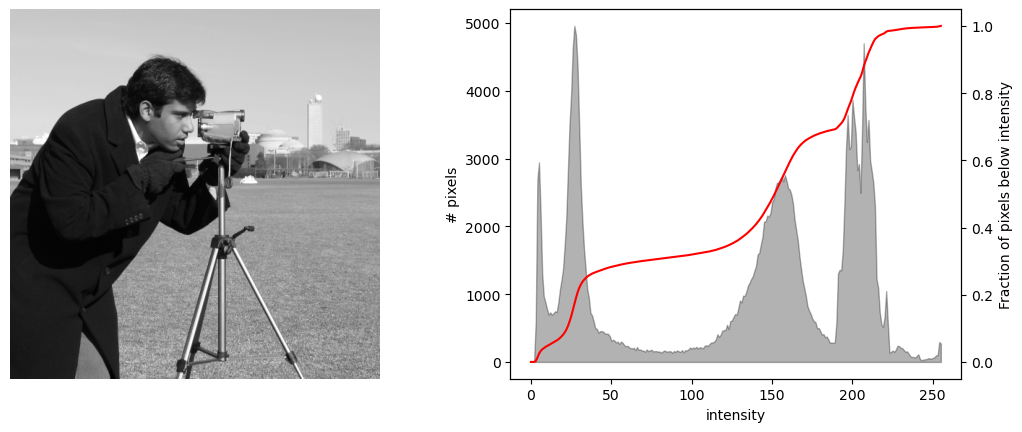

In [294]:
ax_image, ax_hist = imshow_with_histogram(camera)
plot_cdf(camera, ax=ax_hist.twinx())

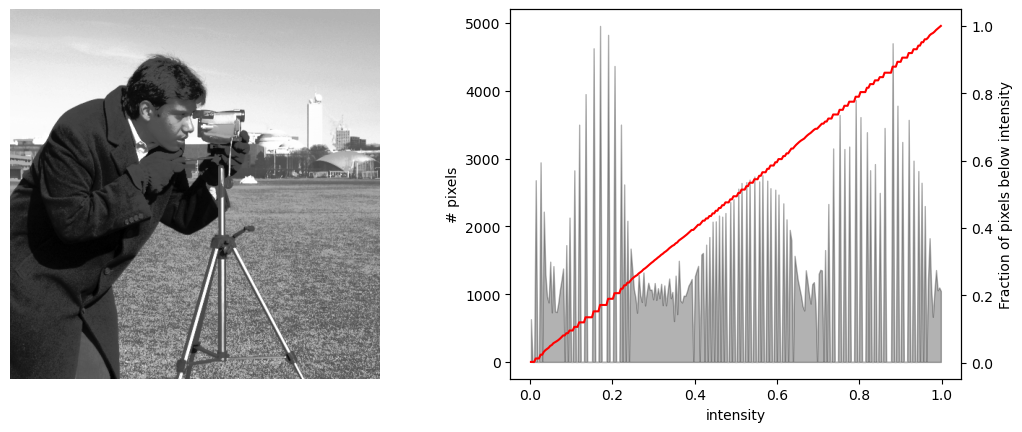

In [297]:
equalized = exposure.equalize_hist(camera)
ax_image, ax_hist = imshow_with_histogram(equalized)
plot_cdf(equalized, ax=ax_hist.twinx())

In [299]:
equalized.dtype

dtype('float64')

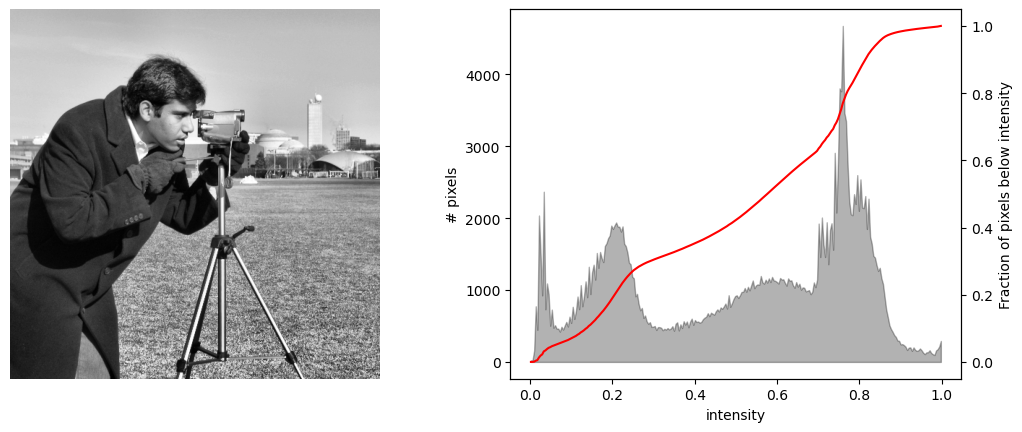

In [302]:
equalized = exposure.equalize_adapthist(camera)
ax_image, ax_hist = imshow_with_histogram(equalized)
plot_cdf(equalized, ax=ax_hist.twinx())

In [303]:
equalized.dtype

dtype('float64')

(<Axes: >, <Axes: xlabel='intensity', ylabel='# pixels'>)

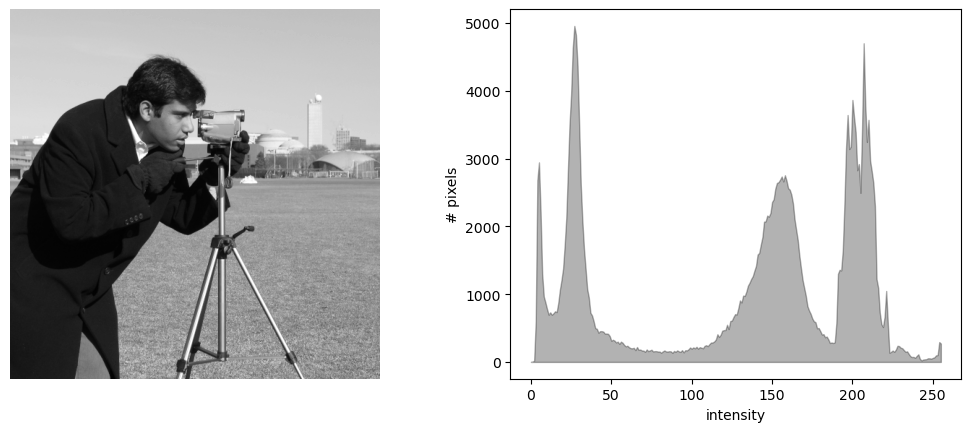

In [305]:
imshow_with_histogram(camera)

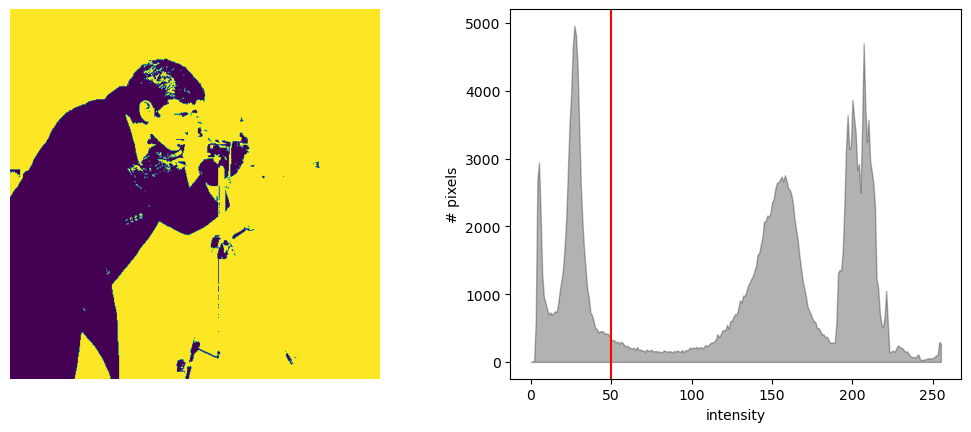

In [307]:
threshold = 50
ax_image, ax_hist = imshow_with_histogram(camera)
ax_image.imshow(camera > threshold)
ax_hist.axvline(threshold, color='red')

In [310]:
from skimage import filters
threshold = filters.threshold_otsu(camera)
print(threshold)

102


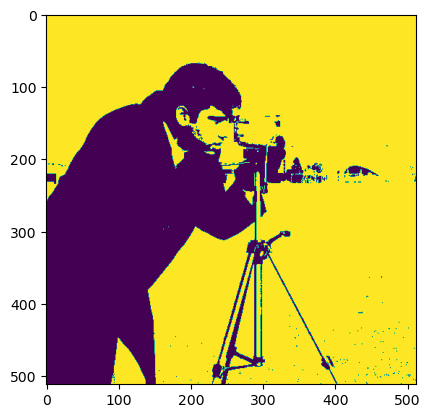

In [314]:
plt.imshow(camera > threshold)

In [317]:
from skimage import color

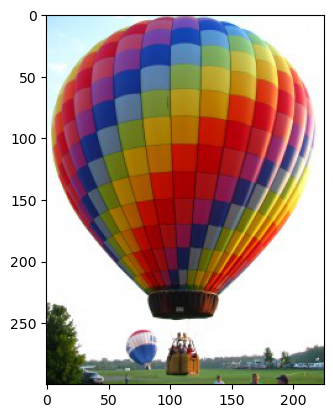

In [319]:
plt.imshow(color_image)

In [321]:
lab_image = color.rgb2lab(color_image)
color_image.shape, lab_image.shape
color_image[:1,:1,:],lab_image[:1,:1,:]

(array([[[180, 227, 253]]], dtype=uint8),
 array([[[ 87.83867906,  -9.30238429, -17.53643398]]]))

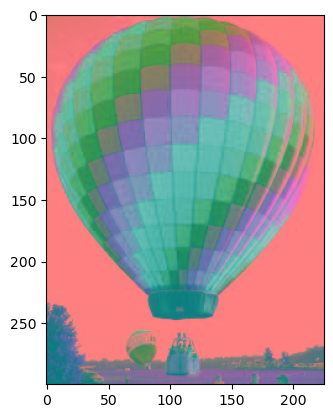

In [324]:
lab_image = (lab_image + [0, 128, 128]) / [100, 255, 255]
plt.imshow(lab_image)

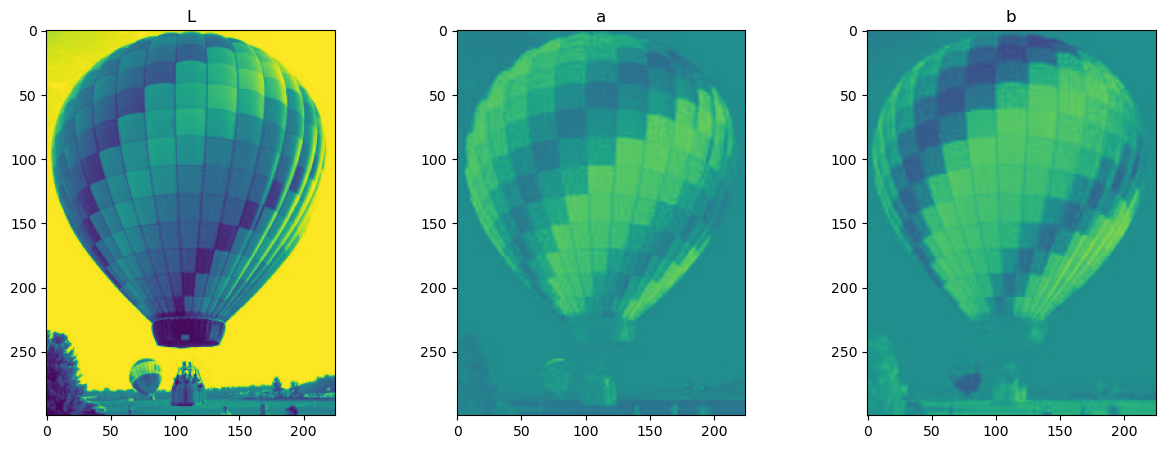

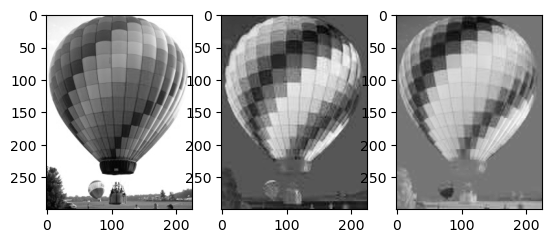

In [327]:
imshow_all(lab_image[..., 0], lab_image[..., 1], lab_image[..., 2], titles=['L', 'a', 'b'])
show_image([lab_image[..., 0], lab_image[..., 1], lab_image[..., 2]], row_plot = 1)

# Mean Filter


Import libraries

In [342]:
import scipy.ndimage

opening the image and converting it to grayscale

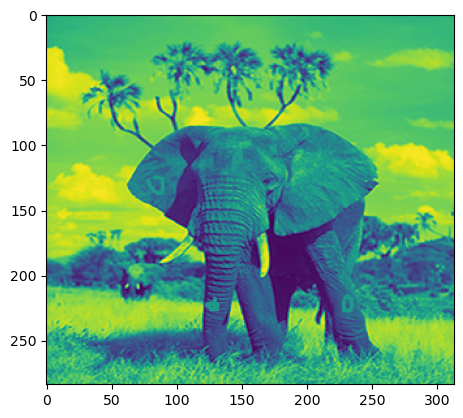

In [345]:
a = imread('image_data/elephant_marked.png', as_gray=True)
plt.imshow(np.array(a)); plt.show()

In [347]:
k = np.ones((5,5))/25
np.sum(k)

1.0

C:\Users\tamir\AppData\Local\Temp\ipykernel_10988\2825389180.py:1: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  b = scipy.ndimage.filters.convolve(a, k)


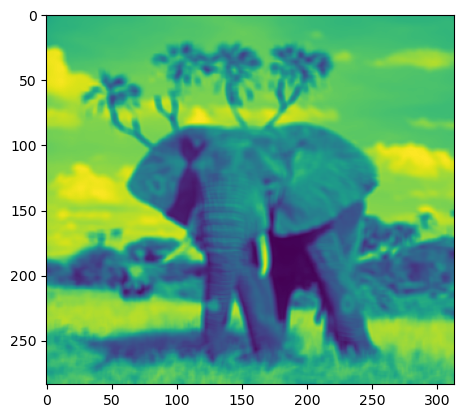

In [349]:
b = scipy.ndimage.filters.convolve(a, k)
plt.imshow(b)
plt.show()

C:\Users\tamir\AppData\Local\Temp\ipykernel_10988\2194985827.py:1: DeprecationWarning: Please import `median_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  b = scipy.ndimage.filters.median_filter(a,size=5, footprint=None,output=None,mode='reflect',cval=0.0,origin=0)


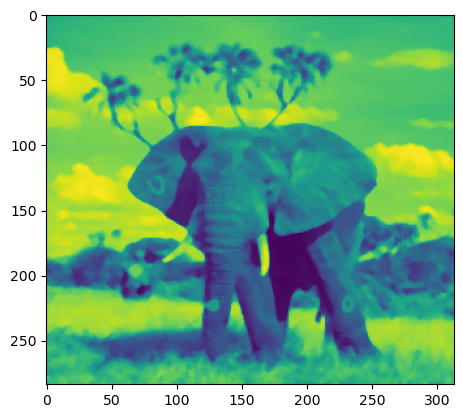

In [340]:
b = scipy.ndimage.filters.median_filter(a,size=5, footprint=None,output=None,mode='reflect',cval=0.0,origin=0)
plt.imshow(b)
plt.show()


C:\Users\tamir\AppData\Local\Temp\ipykernel_10988\4248618147.py:1: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  b = scipy.ndimage.filters.maximum_filter(a,size=5, footprint=None,output=None,mode='reflect',cval=0.0,origin=0)


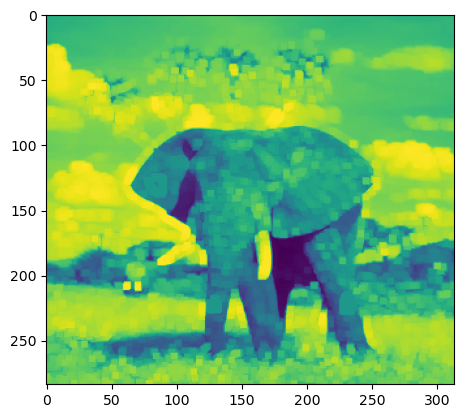

In [97]:
b = scipy.ndimage.filters.maximum_filter(a,size=5, footprint=None,output=None,mode='reflect',cval=0.0,origin=0)
plt.imshow(b)
plt.show()

C:\Users\tamir\AppData\Local\Temp\ipykernel_10988\3165420832.py:1: DeprecationWarning: Please import `minimum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  b = scipy.ndimage.filters.minimum_filter(a,size=5, footprint=None,output=None,mode='reflect',cval=0.0,origin=0)


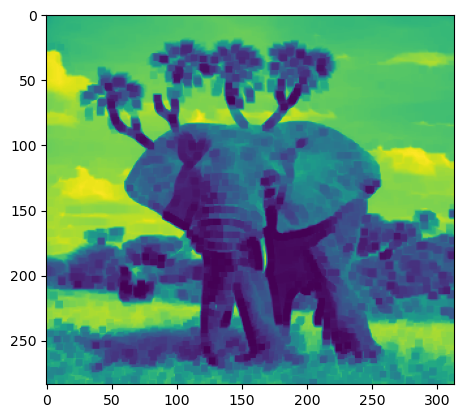

In [98]:
b = scipy.ndimage.filters.minimum_filter(a,size=5, footprint=None,output=None,mode='reflect',cval=0.0,origin=0)
plt.imshow(b)
plt.show()

del(a, b, k)

In [351]:
from skimage import filters, feature

In [353]:
a = imread('image_data/elephant_marked.png', as_gray=True)

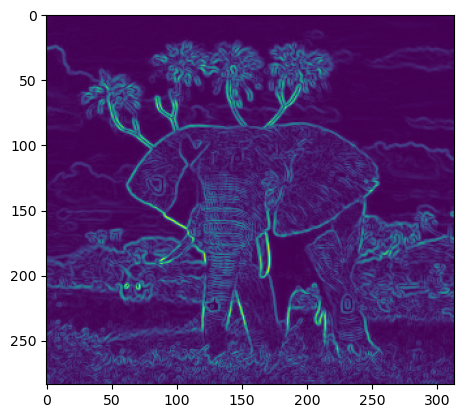

In [355]:
b = filters.sobel(a)
plt.imshow(b)
plt.show()

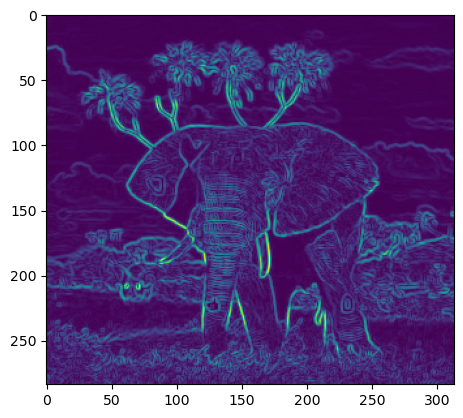

In [357]:
b1 = filters.prewitt(a)
plt.imshow(b1)
plt.show()